# Netflix Movie Recommendation System
## Content-Based Filtering with TF-IDF & Cosine Similarity

**Created By Yonathan Hary Hutagalung**
---
### Introduction

Recommendation systems are one of the most impactful applications of machine learning in everyday life.
From Netflix to Spotify, these systems help users discover new content they are likely to enjoy.

This notebook implements a **Content-Based Filtering (CBF)** recommendation system using the **Netflix Movies Dataset**.
Instead of relying on what other users liked (collaborative filtering), CBF recommends items **similar in content** to what a user has already watched.

### Business Questions
1. Given a movie a user has watched and rated, **which other Netflix movies best match their taste** based on genre, country, and description?
2. How can we **build a user preference profile** from their watch history using a rating-weighted feature vector?
3. How can we **serve personalized recommendations to multiple users** simultaneously using their watch and rating history?

###  Methodology
Both Single and Multi-User modes follow the **rating-weighted pipeline**

| Step | Technique |
|------|----------|
| Text Feature Extraction | TF-IDF Vectorizer on `description` |
| Categorical Features | Multi-hot encoding on `genre` and `country` |
| Feature Weighting | Item-Feature Matrix × User Rating |
| User Profile | Normalized sum → User Feature Vector |
| Similarity | Cosine Similarity |
| Recommendation | Single User & Multi-User CBF |

### IMPORTANT CAUTIONS
**The rating in column is not the movie rating, hence the user can input the rating**


---
## 1. Import Libraries

In [34]:
import numpy as np
import pandas as pd
import scipy.sparse as sp
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import MultiLabelBinarizer

---
## 2. Load Dataset

In [35]:
df = pd.read_csv('NetFlix.csv')
print(f'Dataset shape: {df.shape}')
df.head()

Dataset shape: (7787, 12)


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,genres,description
0,s1,TV Show,3%,NaN,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,14-Aug-20,2020,TV-MA,4,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...
1,s10,Movie,1920,Vikram Bhatt,"Rajneesh Duggal, Adah Sharma, Indraneil Sengup...",India,15-Dec-17,2008,TV-MA,143,"Horror Movies, International Movies, Thrillers",An architect and his wife move into a castle t...
2,s100,Movie,3 Heroines,Iman Brotoseno,"Reza Rahadian, Bunga Citra Lestari, Tara Basro...",Indonesia,5-Jan-19,2016,TV-PG,124,"Dramas, International Movies, Sports Movies",Three Indonesian women break records by becomi...
3,s1000,Movie,Blue Mountain State: The Rise of Thadland,Lev L. Spiro,"Alan Ritchson, Darin Brooks, James Cade, Rob R...",United States,1-Mar-16,2016,R,90,Comedies,New NFL star Thad buys his old teammates' belo...
4,s1001,TV Show,Blue Planet II,NaN,David Attenborough,United Kingdom,3-Dec-18,2017,TV-G,1,"British TV Shows, Docuseries, Science & Nature TV",This sequel to the award-winning nature series...


In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7787 entries, 0 to 7786
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       7787 non-null   object
 1   type          7787 non-null   object
 2   title         7787 non-null   object
 3   director      5398 non-null   object
 4   cast          7069 non-null   object
 5   country       7280 non-null   object
 6   date_added    7777 non-null   object
 7   release_year  7787 non-null   int64 
 8   rating        7780 non-null   object
 9   duration      7787 non-null   int64 
 10  genres        7787 non-null   object
 11  description   7787 non-null   object
dtypes: int64(2), object(10)
memory usage: 730.2+ KB


---
## 3. Exploratory Data Analysis (EDA)

### 3.1 Missing Values

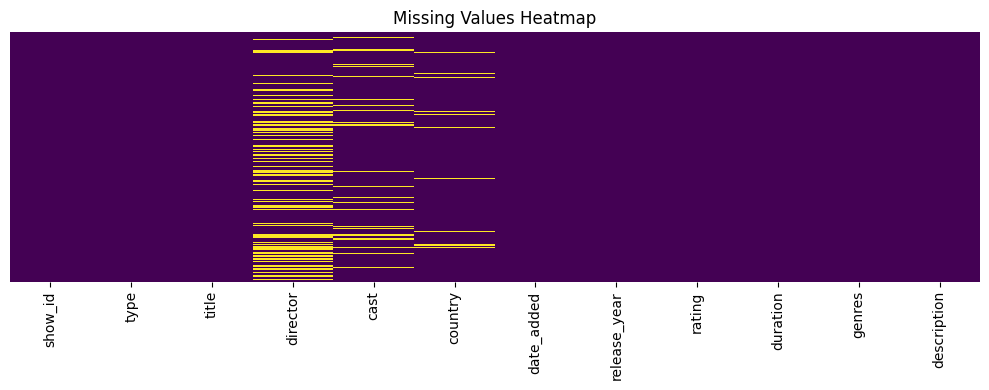

show_id            0
type               0
title              0
director        2389
cast             718
country          507
date_added        10
release_year       0
rating             7
duration           0
genres             0
description        0
dtype: int64


In [37]:
plt.figure(figsize=(10, 4))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Missing Values Heatmap')
plt.tight_layout()
plt.show()
print(df.isnull().sum())

### 3.2 Content Type Distribution (Movies vs TV Shows)

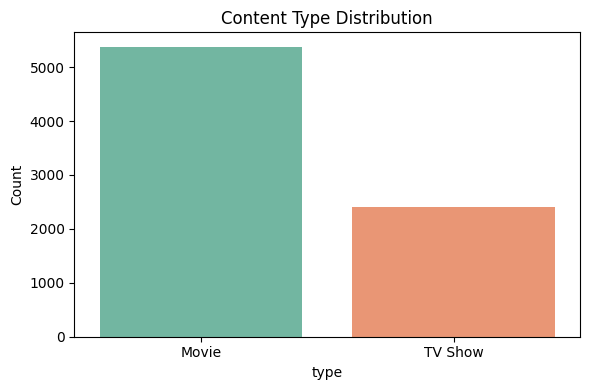

type
Movie      5377
TV Show    2410
Name: count, dtype: int64


In [38]:
type_counts = df['type'].value_counts()
plt.figure(figsize=(6, 4))
sns.barplot(x=type_counts.index, y=type_counts.values, palette='Set2')
plt.title('Content Type Distribution')
plt.ylabel('Count')
plt.tight_layout()
plt.show()
print(type_counts)

### 3.3 Top 10 Countries by Movie Production

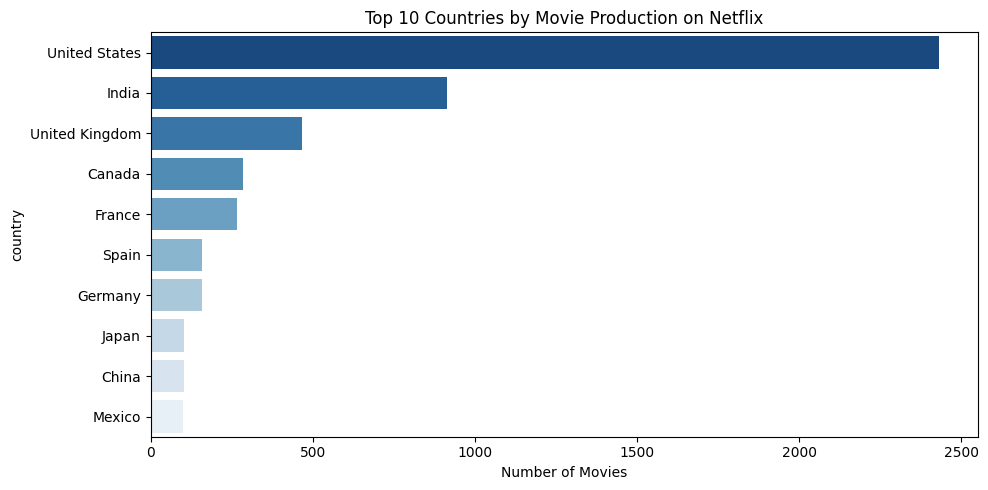

In [39]:
movies_df = df[df['type'] == 'Movie'].copy()
country_counts = movies_df['country'].dropna().str.split(', ').explode().value_counts().head(10)
plt.figure(figsize=(10, 5))
sns.barplot(x=country_counts.values, y=country_counts.index, palette='Blues_r')
plt.title('Top 10 Countries by Movie Production on Netflix')
plt.xlabel('Number of Movies')
plt.tight_layout()
plt.show()

### 3.4 Top 10 Genres

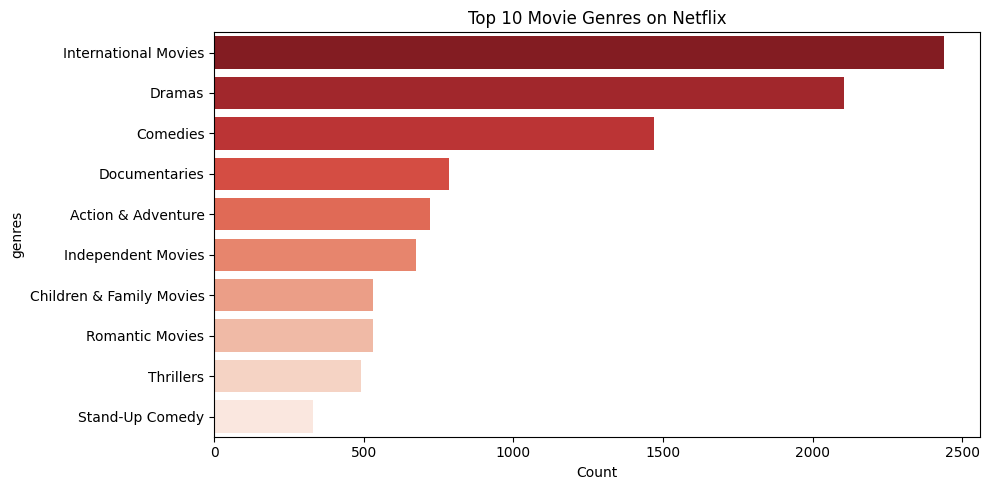

In [40]:
genre_col = 'listed_in' if 'listed_in' in movies_df.columns else 'genres'
genre_counts = movies_df[genre_col].dropna().str.split(', ').explode().value_counts().head(10)
plt.figure(figsize=(10, 5))
sns.barplot(x=genre_counts.values, y=genre_counts.index, palette='Reds_r')
plt.title('Top 10 Movie Genres on Netflix')
plt.xlabel('Count')
plt.tight_layout()
plt.show()

### 3.5 Description Word Count Distribution

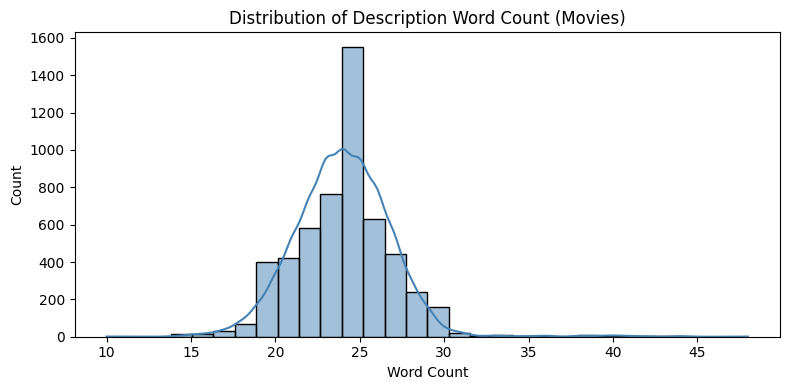

In [41]:
movies_df['desc_word_count'] = movies_df['description'].dropna().apply(lambda x: len(str(x).split()))
plt.figure(figsize=(8, 4))
sns.histplot(movies_df['desc_word_count'], bins=30, kde=True, color='steelblue')
plt.title('Distribution of Description Word Count (Movies)')
plt.xlabel('Word Count')
plt.tight_layout()
plt.show()

---
## 4. Feature Engineering

### 4.1 Filter Movies Only & Handle Missing Values

In [42]:
movies = df[df['type'] == 'Movie'].copy().reset_index(drop=True)
genre_col = 'listed_in' if 'listed_in' in movies.columns else 'genres'

movies['description'] = movies['description'].fillna('')
movies['country'] = movies['country'].fillna('Unknown')
movies[genre_col] = movies[genre_col].fillna('Unknown')

print(f'Total movies: {len(movies)}')
movies[['title', genre_col, 'country', 'description']].head()

Total movies: 5377


,title,genres,country,description
0,1920,"Horror Movies, International Movies, Thrillers",India,An architect and his wife move into a castle t...
1,3 Heroines,"Dramas, International Movies, Sports Movies",Indonesia,Three Indonesian women break records by becomi...
2,Blue Mountain State: The Rise of Thadland,Comedies,United States,New NFL star Thad buys his old teammates' belo...
3,Blue Ruin,"Independent Movies, Thrillers","United States, France",Bad news from the past unhinges vagabond Dwigh...
4,Blue Streak,"Action & Adventure, Comedies","Germany, United States",A jewel thief returns to his hiding place afte...


### 4.2 TF-IDF on Description

In [43]:
tfidf = TfidfVectorizer(stop_words='english', max_features=500)
tfidf_matrix = tfidf.fit_transform(movies['description'])
print(f'TF-IDF matrix shape: {tfidf_matrix.shape}')
print(f'Sample features: {tfidf.get_feature_names_out()[:20]}')

TF-IDF matrix shape: (5377, 500)
Sample features: ['10' 'accident' 'action' 'activist' 'actor' 'adventure' 'age' 'agent'
 'agrees' 'ambitious' 'america' 'american' 'amid' 'ancient' 'angeles'
 'apart' 'army' 'arrives' 'art' 'artist']


### 4.3 Multi-Hot Encoding for Genre & Country

In [44]:
mlb_genre = MultiLabelBinarizer()
genre_matrix = mlb_genre.fit_transform(movies[genre_col].str.split(', '))

mlb_country = MultiLabelBinarizer()
country_matrix = mlb_country.fit_transform(movies['country'].str.split(', '))

print(f'Genre matrix shape:   {genre_matrix.shape}')
print(f'Country matrix shape: {country_matrix.shape}')

Genre matrix shape:   (5377, 20)
Country matrix shape: (5377, 115)


### 4.4 Combine All Features

In [45]:
feature_matrix = sp.hstack([
    tfidf_matrix,
    sp.csr_matrix(genre_matrix),
    sp.csr_matrix(country_matrix)
]).toarray()  # Convert to dense for easy rating multiplication

print(f'Combined feature matrix shape: {feature_matrix.shape}')

# Build title → index mapping
movies = movies.reset_index(drop=True)
title_to_idx = pd.Series(movies.index, index=movies['title'].str.lower()).drop_duplicates()
print(f'Total indexed movies: {len(title_to_idx)}')

Combined feature matrix shape: (5377, 635)
Total indexed movies: 5377


---
## 5. Similarity Measure

We use **Cosine Similarity** to measure how similar two feature vectors are:

$$\text{cosine\_similarity}(A, B) = \frac{A \cdot B}{\|A\| \|B\|}$$

- Result = **0** → no similarity
- Result = **1** → identical content

---
## 6. Content-Based Filtering

Both Single User and Multi-User modes use the **same rating-weighted pipeline** from the lecture:

| Step | Operation |
|------|----------|
| 1 | Item-Feature Matrix (binary: TF-IDF + genre + country) |
| 2 | Multiply each movie's feature row × user rating |
| 3 | Sum all weighted rows → raw User Feature Vector |
| 4 | Normalize ÷ total rating sum → final User Feature Vector |
| 5 | Cosine Similarity: User Feature Vector vs all unwatched movies |
| 6 | Sort descending → Top-N Recommendations |


In [46]:
def build_user_feature_vector(watched_ratings):
    weighted_sum = np.zeros(feature_matrix.shape[1])
    total_rating = 0

    for title, rating in watched_ratings.items():
        if rating > 0 and title.lower() in title_to_idx:
            idx = title_to_idx[title.lower()]
            # Step 1 & 2: feature row × rating, then accumulate
            weighted_sum += feature_matrix[idx] * rating
            total_rating += rating

    if total_rating == 0:
        return weighted_sum

    # Step 3: normalize
    return weighted_sum / total_rating


def recommend(watched_ratings, top_n=5):
    user_vec = build_user_feature_vector(watched_ratings)
    sim_scores = cosine_similarity([user_vec], feature_matrix)[0]

    # Exclude already watched movies
    watched_indices = set(
        title_to_idx[t.lower()] for t in watched_ratings
        if t.lower() in title_to_idx and watched_ratings[t] > 0
    )

    scores_filtered = [
        (i, s) for i, s in enumerate(sim_scores)
        if i not in watched_indices
    ]
    scores_sorted = sorted(scores_filtered, key=lambda x: x[1], reverse=True)[:top_n]

    indices = [s[0] for s in scores_sorted]
    scores  = [round(s[1], 4) for s in scores_sorted]

    result = movies[['title', genre_col, 'country']].iloc[indices].copy()
    result['similarity_score'] = scores
    return result.reset_index(drop=True)

### 6.1 Single User Recommendation

The user provides **one or more movies they've watched along with their rating (1–10)**.
The system builds their preference profile using the rating-weighted feature vector pipeline.

In [47]:
single_user_ratings = {
    'Inception': 9,
}

print('Single User Recommendations')
print(f'Based on: {single_user_ratings}\n')
recommend(single_user_ratings, top_n=5)

Single User Recommendations
Based on: {'Inception': 9}



,title,genres,country,similarity_score
0,Clash of the Titans,"Action & Adventure, Sci-Fi & Fantasy","United States, United Kingdom, Australia",0.6667
1,Knowing,"Sci-Fi & Fantasy, Thrillers","United States, United Kingdom, Australia",0.6667
2,Terminator 3: Rise of the Machines,"Action & Adventure, Sci-Fi & Fantasy","United States, Germany, United Kingdom",0.6667
3,The Brothers Grimm,"Action & Adventure, Sci-Fi & Fantasy","United States, Czech Republic, United Kingdom",0.6667
4,Transcendence,"Sci-Fi & Fantasy, Thrillers","United Kingdom, China, United States",0.6667


In [48]:
# Try with multiple watched movies (still single user)
single_user_ratings_multi = {
    'Inception':    9,
    'Bird Box':     7,
    'The Irishman': 8,
}

print('Single User (Multi-Watch History) Recommendations')
print(f'Based on: {single_user_ratings_multi}\n')
recommend(single_user_ratings_multi, top_n=5)

Single User (Multi-Watch History) Recommendations
Based on: {'Inception': 9, 'Bird Box': 7, 'The Irishman': 8}



,title,genres,country,similarity_score
0,See You Yesterday,"Dramas, Sci-Fi & Fantasy, Thrillers",United States,0.7739
1,Brooklyn's Finest,"Dramas, Thrillers",United States,0.7232
2,Extinction,"Action & Adventure, Dramas, Sci-Fi & Fantasy",United States,0.7208
3,Space Cowboys,"Action & Adventure, Dramas, Sci-Fi & Fantasy",United States,0.7123
4,Selfless,"Sci-Fi & Fantasy, Thrillers",United States,0.7112


### 6.2 Multiple User Recommendation

We simulate a **User-Item Rating Matrix** (same as the lecture notebook).
Each user's rating-weighted feature vector is built independently — no influence between users.

In [49]:
# User-Item Rating Matrix (0 = not watched)
user_item_data = {
    'user':          ['User 1', 'User 2', 'User 3', 'User 4'],
    'Inception':     [9, 8, 0, 0],
    'The Irishman':  [0, 7, 9, 0],
    'Bird Box':      [8, 0, 7, 9],
    'Mank':          [0, 0, 8, 7],
}
df_user_items = pd.DataFrame(user_item_data).set_index('user')
df_user_items

,Inception,The Irishman,Bird Box,Mank
user,,,,
User 1,9,0,8,0
User 2,8,7,0,0
User 3,0,9,7,8
User 4,0,0,9,7


In [50]:
# Generate recommendations for all users
for user in df_user_items.index:
    watched_ratings = {
        title: rating
        for title, rating in df_user_items.loc[user].items()
        if rating > 0
    }
    print(f'\n Recommendations for {user}')
    print(f'   Watched & rated: {watched_ratings}')
    print(recommend(watched_ratings, top_n=3).to_string(index=False))


 Recommendations for User 1
   Watched & rated: {'Inception': 9, 'Bird Box': 8}
            title                              genres       country  similarity_score
         Selfless         Sci-Fi & Fantasy, Thrillers United States            0.7518
See You Yesterday Dramas, Sci-Fi & Fantasy, Thrillers United States            0.7499
Lady in the Water         Sci-Fi & Fantasy, Thrillers United States            0.7247

 Recommendations for User 2
   Watched & rated: {'Inception': 8, 'The Irishman': 7}
         title                                       genres                                country  similarity_score
    Extinction Action & Adventure, Dramas, Sci-Fi & Fantasy                          United States            0.6972
 Space Cowboys Action & Adventure, Dramas, Sci-Fi & Fantasy                          United States            0.6852
V for Vendetta Action & Adventure, Dramas, Sci-Fi & Fantasy United States, United Kingdom, Germany            0.6799

 Recommendations for 

---
## 7. Summary

- **Content-Based Filtering** was implemented using TF-IDF on movie descriptions combined with multi-hot encoded genre and country features.
- **Both Single User and Multi-User modes** use the same rating-weighted user feature vector pipeline, consistent with the lecture framework.
- **Cosine Similarity** was used to measure alignment between the user's preference profile and unseen movies.
- Key insight: Higher-rated genres/descriptions dominate the user feature vector, driving more accurate and personalized recommendations.
